In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3
from pathlib import Path 

PROJECT_ROOT = Path.cwd().parent

DATA = 'churn.db'

conn = sqlite3.connect(DATA)


query =  """
SELECT * 

FROM customer_churn_raw
"""

df = pd.read_sql(query, conn)

# Overview of data

In [2]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [3]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [4]:
# # Total charges should be int, not object
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

df['Total Charges'].dtypes

dtype('float64')

In [5]:
df.isna().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [6]:
df[df['Total Charges'].isnull()].describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,11.0,11.000000,11.000000,11.000000,11.0,11.000000,0.0,11.0,11.000000,11.000000
mean,1.0,92839.272727,35.729120,-119.584723,0.0,41.418182,NaN,0.0,48.545455,3665.545455
std,0.0,2011.647588,2.220277,2.446604,0.0,23.831484,NaN,0.0,14.445509,1419.168233
min,1.0,90029.000000,33.739412,-123.835041,0.0,19.700000,NaN,0.0,27.000000,2019.000000
25%,1.0,91247.000000,34.027626,-122.085503,0.0,20.125000,NaN,0.0,40.000000,2320.500000
50%,1.0,92585.000000,34.144703,-118.262263,0.0,25.750000,NaN,0.0,48.000000,3763.000000
75%,1.0,94703.000000,37.192743,-117.970833,0.0,58.975000,NaN,0.0,59.000000,4920.000000
max,1.0,95569.000000,40.363446,-117.173334,0.0,80.850000,NaN,0.0,69.000000,5504.000000


### The only columns with NaN value is Churn reason and Total Charges.

1. Churn Reason: 
    - Only customers churned have reasons, this column will be removed for modellign 
2. Total Charges: 
    - There are 11 new customers with 0 tenure month, and therefore 0 total charges.
    - These NaN values will be filled with 0. 



In [7]:
df['Total Charges'] = df['Total Charges'].fillna(0)

df.isna().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [8]:
df.select_dtypes(include=['float64', 'int64']).corr()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,NaN,1.000000,0.895743,-0.784271,0.001041,-0.004596,-0.000884,0.003346,-0.002769,-0.003562
Latitude,NaN,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.009944,-0.003384,-0.007684,0.000886
Longitude,NaN,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.008876,0.004594,0.004260,0.000485
Tenure Months,NaN,0.001041,-0.001631,-0.001678,1.000000,0.247900,0.826178,-0.352229,-0.224987,0.396406
Monthly Charges,NaN,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.651174,0.193356,0.133754,0.098693
Total Charges,NaN,-0.000884,-0.009944,0.008876,0.826178,0.651174,1.000000,-0.198324,-0.123410,0.342091
Churn Value,NaN,0.003346,-0.003384,0.004594,-0.352229,0.193356,-0.198324,1.000000,0.664897,-0.127463
Churn Score,NaN,-0.002769,-0.007684,0.004260,-0.224987,0.133754,-0.123410,0.664897,1.000000,-0.079782
CLTV,NaN,-0.003562,0.000886,0.000485,0.396406,0.098693,0.342091,-0.127463,-0.079782,1.000000


## The following columns will be removed 

Count - Need to be removed from the dataset, as it does not provide any valueable information

Churn Score - High correlated with Churn Value. The prediction made by a different model (IBM SPSS), this column will be removed to avoid data leakage during modelling.

Churn Reason - This column will be removed to avoid data leakage during modelling

CustomerID - Contains no meaningful information

Longitude & Latituude & Lat Long & Zip Code & State & Country- Will also be removed, as it is just geographical information which does not help for predicting customer churn. However these will be used for analysing. 

In [9]:
df_orig = df.copy()

# Dropping the columns 
df = df.drop(columns=['Zip Code', 'CustomerID', 'Count', 'Churn Score', 'Churn Label', 'Churn Reason',  
                      'Longitude', 'Latitude', 'Lat Long', 'State', 'Country', 'Partner'])
df.head(5)

,City,Gender,Senior Citizen,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Los Angeles,Male,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Los Angeles,Female,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Los Angeles,Female,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372
3,Los Angeles,Female,No,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Los Angeles,Male,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340


In [10]:
# Checking for columns with high-cardinality 

for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} unique values")

City: 1129 unique values
Gender: 2 unique values
Senior Citizen: 2 unique values
Dependents: 2 unique values
Phone Service: 2 unique values
Multiple Lines: 3 unique values
Internet Service: 3 unique values
Online Security: 3 unique values
Online Backup: 3 unique values
Device Protection: 3 unique values
Tech Support: 3 unique values
Streaming TV: 3 unique values
Streaming Movies: 3 unique values
Contract: 3 unique values
Paperless Billing: 2 unique values
Payment Method: 4 unique values


In [11]:
# Since there are 1129 unique cities, one-hot-encoding them produces 1129 new columns,
# We will group them with major cities vs other cities

major_cities = ['Los Angeles', 'San Francisco', 'San Diego']

df['City'] = df['City'].where(df['City'].isin(major_cities), 'Other')

df.City.unique()

array(['Los Angeles', 'Other', 'San Diego', 'San Francisco'], dtype=object)

In [12]:
# One-hot-encoding for categorical vairables 
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = df.select_dtypes(include=['object']).columns.tolist()
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ct = ColumnTransformer(
    transformers=[('encoder', one_hot_encoder, categorical_features)],
    remainder='passthrough'
)


df_encoded = ct.fit_transform(df)


feature_names = ct.get_feature_names_out(input_features=df.columns)
df_encoded = pd.DataFrame(df_encoded, columns=feature_names)

df_encoded.describe()

,encoder__City_Los Angeles,encoder__City_Other,encoder__City_San Diego,encoder__City_San Francisco,encoder__Gender_Female,encoder__Gender_Male,encoder__Senior Citizen_No,encoder__Senior Citizen_Yes,encoder__Dependents_No,encoder__Dependents_Yes,...,encoder__Paperless Billing_Yes,encoder__Payment Method_Bank transfer (automatic),encoder__Payment Method_Credit card (automatic),encoder__Payment Method_Electronic check,encoder__Payment Method_Mailed check,remainder__Tenure Months,remainder__Monthly Charges,remainder__Total Charges,remainder__Churn Value,remainder__CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.043305,0.920630,0.021298,0.014766,0.495244,0.504756,0.837853,0.162147,0.768990,0.231010,...,0.592219,0.219225,0.216101,0.335794,0.228880,32.371149,64.761692,2279.734304,0.265370,4400.295755
std,0.203558,0.270334,0.144385,0.120625,0.500013,0.500013,0.368612,0.368612,0.421508,0.421508,...,0.491457,0.413751,0.411613,0.472301,0.420141,24.559481,30.090047,2266.794470,0.441561,1183.057152
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,2003.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,35.500000,398.550000,0.000000,3469.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000,70.350000,1394.550000,0.000000,4527.000000
75%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,55.000000,89.850000,3786.600000,1.000000,5380.500000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,118.750000,8684.800000,1.000000,6500.000000


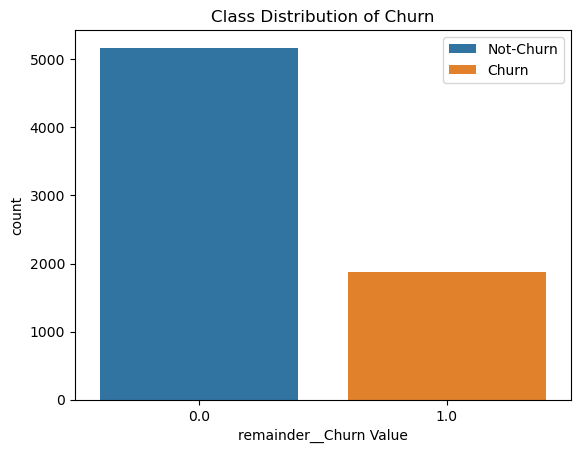

In [13]:
sns.countplot(x='remainder__Churn Value', data=df_encoded, label=['Not-Churn', 'Churn'])
plt.title("Class Distribution of Churn")
plt.legend()
plt.show()

We can see that there is a strong class imbalance between the two; therefore this data will need to be resampled; Using the SMOTE technique.

In [20]:
# Export the cleaned version of data
import os
from pathlib import Path 

path = PROJECT_ROOT/'data'/'processed'

df_encoded.to_csv(path/'Cleaned_csv.csv')